# TP : Prevision des ventes d'assurance

**Navigation** : [Index](README.md) | [<< ML-4-Evaluation](ML-4-Evaluation.ipynb)

## Objectifs d'apprentissage

A la fin de ce TP, vous saurez :
1. Construire un modele de regression avec ML.NET (SDCA)
2. Separer les donnees en jeux d'entrainement et de test
3. Evaluer les performances d'un modele de regression
4. Comparer une approche frequentiste (ML.NET) avec une approche bayesienne (Infer.NET)
5. Visualiser les predictions avec ScottPlot

### Prerequis
- .NET SDK 9.0+
- Notebooks ML-1 a ML-4 completes
- Connaissances de base en regression

### Duree estimee : 45-60 minutes

> **Repère bibliographique.** Ce TP confronte deux paradigmes de régression : l'approche **fréquentiste** via ML.NET (algorithme SDCA, Shalev-Shwartz & Zhang, *Stochastic Dual Coordinate Ascent*, 2013) et l'approche **bayésienne** via Infer.NET (Winn & Minka, *Probabilistic Programming with Infer.NET*, Microsoft Research, 2009), qui quantifie l'incertitude par des distributions *a posteriori* sur les poids. Voir Bishop, *Pattern Recognition and Machine Learning*, Springer, 2006, chap. 3 pour la théorie de la régression bayésienne linéaire.

In [1]:
#r "nuget: Microsoft.ML, 5.0.0"
#r "nuget: Microsoft.ML.Probabilistic, 0.4.2504.701"
#r "nuget: Microsoft.ML.Probabilistic.Compiler, 0.4.2504.701"
#r "nuget: ScottPlot, 5.0.55"

using System;
using System.Linq;
using Microsoft.ML;
using Microsoft.ML.Data;
using System.Collections.Generic;
using ScottPlot;
using Microsoft.DotNet.Interactive;

Console.WriteLine("Packages charges avec succes !");

The below script needs to be able to find the current output cell; this is an easy method to get it.

Installed Packages Microsoft.ML, 5.0.0 Microsoft.ML.Probabilistic, 0.4.2504.701 Microsoft.ML.Probabilistic.Compiler, 0.4.2504.701 ScottPlot, 5.0.55

Loading extensions from `C:\Users\jsboi\.nuget\packages\skiasharp\2.88.9\interactive-extensions\dotnet\SkiaSharp.DotNet.Interactive.dll`

Packages charges avec succes !


Les packages necessaires sont :
- **Microsoft.ML** : framework principal de machine learning
- **Microsoft.ML.Probabilistic** : inference bayesienne (Infer.NET)
- **ScottPlot** : visualisations 2D interactives

## Partie 1 : Regression simple avec ML.NET

Dans cette premiere partie, nous construisons un modele de regression lineaire avec l'algorithme SDCA (Stochastic Dual Coordinate Ascent) pour predire le montant des ventes d'assurance.

**Approche** : Entrainement sur l'ensemble complet des donnees (sans separation train/test).

### Donnees

| Variable | Type | Description |
|----------|------|-------------|
| Age | float | Age du client |
| Income | float | Revenu annuel |
| FamilyStatus | float | Situation familiale (0=Celibataire, 1=Marie) |
| EducationLevel | float | Niveau d'education (0=Lycee, 1=Licence, 2=Master) |
| ContractType | float | Type de contrat (0=Sante, 1=Invalidite, 2=Vie) |
| ContractDuration | float | Duree du contrat (annees) |
| PremiumAmount | float | Montant de la prime |
| Region | float | Region (0=Urbain, 1=Rural) |
| **SalesAmount** | float | **Variable cible** : montant des ventes |

Nombre d'echantillons : 15



Entrainement du modele SDCA...


Modele entraine avec succes !



=== Metriques d'evaluation ===


R-squared : 0,7231


Mean Absolute Error : 1707,50


Root Mean Squared Error : 2273,52



Prediction pour Age=35, Income=60000 : 12215,13



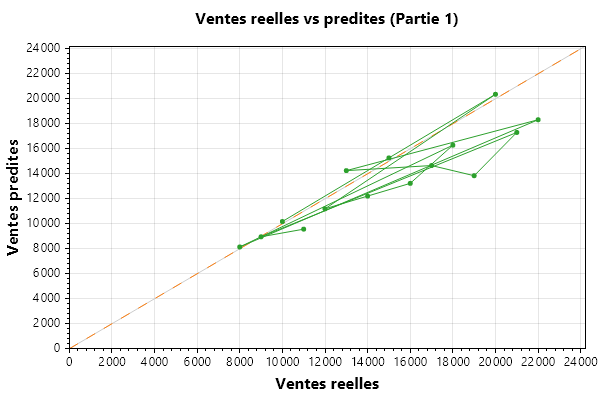


warning CS1701: En supposant que la référence d'assembly 'Microsoft.AspNetCore.Html.Abstractions, Version=2.3.0.0, Culture=neutral, PublicKeyToken=adb9793829ddae60' utilisée par 'Microsoft.DotNet.Interactive' correspond à l'identité 'Microsoft.AspNetCore.Html.Abstractions, Version=10.0.0.0, Culture=neutral, PublicKeyToken=adb9793829ddae60' de 'Microsoft.AspNetCore.Html.Abstractions', il se peut que vous deviez fournir une stratégie runtime



In [2]:
// Definir les schemas des donnees d'entree et de sortie
public class SalesData
{
    public float Age { get; set; }
    public float Income { get; set; }
    public float FamilyStatus { get; set; }
    public float EducationLevel { get; set; }
    public float ContractType { get; set; }
    public float ContractDuration { get; set; }
    public float PremiumAmount { get; set; }
    public float Region { get; set; }
    public float SalesAmount { get; set; }
}

public class SalesPrediction
{
    [ColumnName("Score")]
    public float SalesAmount { get; set; }
}

// Creer et preparer les donnees d'entrainement
var mlContext = new MLContext(seed: 42);

// Exemple de donnees d'entrainement
var trainingData = new List<SalesData>
{
    new SalesData { Age = 30, Income = 50000, FamilyStatus = 1, EducationLevel = 1, ContractType = 0, ContractDuration = 5, PremiumAmount = 300, Region = 0, SalesAmount = 10000 },
    new SalesData { Age = 45, Income = 75000, FamilyStatus = 1, EducationLevel = 2, ContractType = 1, ContractDuration = 10, PremiumAmount = 500, Region = 0, SalesAmount = 15000 },
    new SalesData { Age = 50, Income = 100000, FamilyStatus = 0, EducationLevel = 2, ContractType = 2, ContractDuration = 15, PremiumAmount = 700, Region = 1, SalesAmount = 20000 },
    new SalesData { Age = 30, Income = 55000, FamilyStatus = 0, EducationLevel = 1, ContractType = 1, ContractDuration = 5, PremiumAmount = 350, Region = 1, SalesAmount = 12000 },
    new SalesData { Age = 40, Income = 60000, FamilyStatus = 1, EducationLevel = 0, ContractType = 0, ContractDuration = 8, PremiumAmount = 400, Region = 0, SalesAmount = 14000 },
    new SalesData { Age = 35, Income = 65000, FamilyStatus = 0, EducationLevel = 2, ContractType = 2, ContractDuration = 7, PremiumAmount = 450, Region = 1, SalesAmount = 16000 },
    new SalesData { Age = 55, Income = 80000, FamilyStatus = 1, EducationLevel = 1, ContractType = 0, ContractDuration = 10, PremiumAmount = 600, Region = 1, SalesAmount = 18000 },
    new SalesData { Age = 25, Income = 40000, FamilyStatus = 0, EducationLevel = 0, ContractType = 1, ContractDuration = 3, PremiumAmount = 250, Region = 0, SalesAmount = 8000 },
    new SalesData { Age = 65, Income = 90000, FamilyStatus = 1, EducationLevel = 2, ContractType = 2, ContractDuration = 12, PremiumAmount = 750, Region = 0, SalesAmount = 22000 },
    new SalesData { Age = 50, Income = 70000, FamilyStatus = 0, EducationLevel = 1, ContractType = 1, ContractDuration = 15, PremiumAmount = 500, Region = 1, SalesAmount = 13000 },
    new SalesData { Age = 38, Income = 72000, FamilyStatus = 1, EducationLevel = 2, ContractType = 0, ContractDuration = 9, PremiumAmount = 520, Region = 1, SalesAmount = 17000 },
    new SalesData { Age = 44, Income = 68000, FamilyStatus = 1, EducationLevel = 1, ContractType = 2, ContractDuration = 11, PremiumAmount = 570, Region = 0, SalesAmount = 19000 },
    new SalesData { Age = 60, Income = 85000, FamilyStatus = 1, EducationLevel = 2, ContractType = 1, ContractDuration = 13, PremiumAmount = 650, Region = 0, SalesAmount = 21000 },
    new SalesData { Age = 27, Income = 44000, FamilyStatus = 0, EducationLevel = 0, ContractType = 0, ContractDuration = 4, PremiumAmount = 300, Region = 1, SalesAmount = 9000 },
    new SalesData { Age = 31, Income = 47000, FamilyStatus = 0, EducationLevel = 1, ContractType = 1, ContractDuration = 6, PremiumAmount = 320, Region = 0, SalesAmount = 11000 },
};

Console.WriteLine($"Nombre d'echantillons : {trainingData.Count}");

// Charger les donnees d'entrainement
var trainingDataView = mlContext.Data.LoadFromEnumerable(trainingData);

// Definir la pipeline d'apprentissage automatique
var pipeline = mlContext.Transforms.Concatenate("Features",
                                                 "Age",
                                                 "Income",
                                                 "FamilyStatus",
                                                 "EducationLevel",
                                                 "ContractType",
                                                 "ContractDuration",
                                                 "PremiumAmount",
                                                 "Region")
    .Append(mlContext.Regression.Trainers.Sdca(labelColumnName: "SalesAmount", maximumNumberOfIterations: 100));

// Entrainer le modele
Console.WriteLine("\nEntrainement du modele SDCA...");
var model = pipeline.Fit(trainingDataView);
Console.WriteLine("Modele entraine avec succes !");

// Evaluer le modele
var testData = trainingDataView;
var predictions = model.Transform(testData);
var metrics = mlContext.Regression.Evaluate(predictions, labelColumnName: "SalesAmount");

Console.WriteLine("\n=== Metriques d'evaluation ===");
Console.WriteLine($"R-squared : {metrics.RSquared:F4}");
Console.WriteLine($"Mean Absolute Error : {metrics.MeanAbsoluteError:F2}");
Console.WriteLine($"Root Mean Squared Error : {metrics.RootMeanSquaredError:F2}");

// Faire une prediction
var predictionFunc = mlContext.Model.CreatePredictionEngine<SalesData, SalesPrediction>(model);
var newSalesData = new SalesData { Age = 35, Income = 60000, FamilyStatus = 1, EducationLevel = 1, ContractType = 0, ContractDuration = 5, PremiumAmount = 400, Region = 0 };
var prediction = predictionFunc.Predict(newSalesData);

Console.WriteLine($"\nPrediction pour Age=35, Income=60000 : {prediction.SalesAmount:F2}");

// Collecter les donnees pour le graphique
var actualSales = trainingData.Select(x => (double)x.SalesAmount).ToArray();
var predictedSales = mlContext.Data.CreateEnumerable<SalesPrediction>(predictions, reuseRowObject: false).Select(x => (double)x.SalesAmount).ToArray();
var ages = trainingData.Select(x => (double)x.Age).ToArray();

// Graphique : Reel vs Predit
var plt = new ScottPlot.Plot();
plt.Title("Ventes reelles vs predites (Partie 1)");
plt.XLabel("Ventes reelles");
plt.YLabel("Ventes predites");

// Ligne diagonale parfaite
var maxVal = Math.Max(actualSales.Max(), predictedSales.Max()) * 1.1;
plt.Add.Line(0, 0, maxVal, maxVal).Color = ScottPlot.Color.FromHex("#CCCCCC");
plt.Add.Line(0, 0, maxVal, maxVal).LinePattern = ScottPlot.LinePattern.Dashed;

// Points de donnees
plt.Add.Scatter(actualSales, predictedSales);

plt.Axes.SetLimits(0, maxVal, 0, maxVal);
display(HTML(plt.GetPngHtml(600, 400)));


### Interpretation des resultats (Partie 1)

Ce premier modele presente une **limitation importante** : il utilise les memes donnees pour l'entrainement ET l'evaluation. Cela conduit a un biais d'evaluation (overfitting non detecte).

| Metrique | Signification |
|----------|---------------|
| R-squared | Proportion de variance expliquee (1.0 = parfait) |
| Mean Absolute Error | Erreur moyenne en valeur absolue |

> **Point critique** : Un R eleve sur les donnees d'entrainement ne garantit pas une bonne generalisation.

**Visualisation** : Le graphique montre les ventes reelles (axe X) vs predites (axe Y). Les points proches de la diagonale indiquent de bonnes predictions.

### Exercice 1 : Predictions par lot et analyse des residus

Utilisez le modele de la Partie 1 pour predire les ventes de 5 nouveaux clients avec des profils varies (jeune celibataire rural, senior marie urbain, etc.). Calculez les residus (erreur = prediction - valeur attendue) et affichez-les dans un tableau.

**Indice** : Creez une liste de 5 nouveaux `SalesData` avec des combinaisons variees d'Age, Income, FamilyStatus, etc. Utilisez `predictionFunc.Predict()` pour chaque client. Les residus permettent de detecter si le modele sur-estime ou sous-estime systematiquement certains profils.

In [3]:
// Exercice 1 : Predictions par lot et analyse des residus
// TODO etudiant : Creez 5 profils varies et analysez les residus de prediction
// Indice : residu = prediction - valeur_reelle_attendue
// Etape 1 : definir 5 nouveaux profils de clients (varier Age, Income, Region, etc.)
// Etape 2 : pour chaque profil, utiliser predictionFunc.Predict() pour obtenir la prediction
// Etape 3 : definir des valeurs attendues realistes pour chaque profil
// Etape 4 : calculer et afficher les residus dans un tableau formaté

// var residualAnalysis = ... // TODO etudiant : remplacer par l'analyse des residus
Console.WriteLine("Exercice a completer : predictions par lot et analyse des residus");

Exercice a completer : predictions par lot et analyse des residus


## Partie 2 : Regression amelioree (Train/Test Split)

Pour obtenir une evaluation plus fiable, nous separons les donnees en :
- **80% entrainement** : pour apprendre les parametres du modele
- **20% test** : pour evaluer la generalisation

**Ameliorations par rapport a la Partie 1** :
1. Separation train/test avec `TrainTestSplit`
2. One-hot encoding des variables categorielles
3. Normalisation Min-Max des features
4. Evaluation separee sur train ET test

=== Division des donnees ===


Entrainement : 13 echantillons (80%)


Test : 2 echantillons (20%)



Entrainement du modele ameliore...


Modele entraine avec succes !


...

MAE : 852,75



=== Analyse ===


Ecart R2 (Train - Test) : 1,0300


ATTENTION : Possible surapprentissage detecte !



Prediction pour Age=35, Income=60000 : 12467,01



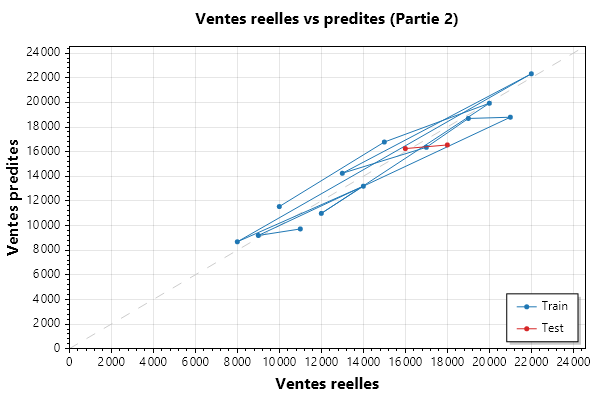


warning CS1701: En supposant que la référence d'assembly 'Microsoft.AspNetCore.Html.Abstractions, Version=2.3.0.0, Culture=neutral, PublicKeyToken=adb9793829ddae60' utilisée par 'Microsoft.DotNet.Interactive' correspond à l'identité 'Microsoft.AspNetCore.Html.Abstractions, Version=10.0.0.0, Culture=neutral, PublicKeyToken=adb9793829ddae60' de 'Microsoft.AspNetCore.Html.Abstractions', il se peut que vous deviez fournir une stratégie runtime



In [4]:
var mlContext2 = new MLContext(seed: 42);

// Charger les donnees
var fullDataView = mlContext2.Data.LoadFromEnumerable(trainingData);

// Separer les donnees entre entrainement et test (80% entrainement, 20% test)
var trainTestData = mlContext2.Data.TrainTestSplit(fullDataView, testFraction: 0.2);
var trainDataView = trainTestData.TrainSet;
var testDataView = trainTestData.TestSet;

var trainCount = mlContext2.Data.CreateEnumerable<SalesData>(trainDataView, reuseRowObject: false).Count();
var testCount = mlContext2.Data.CreateEnumerable<SalesData>(testDataView, reuseRowObject: false).Count();

Console.WriteLine($"=== Division des donnees ===");
Console.WriteLine($"Entrainement : {trainCount} echantillons (80%)");
Console.WriteLine($"Test : {testCount} echantillons (20%)");

// Definir la pipeline avec preprocessing
var pipeline2 = mlContext2.Transforms.Categorical.OneHotEncoding(new[]
    {
        new InputOutputColumnPair("FamilyStatus"),
        new InputOutputColumnPair("EducationLevel"),
        new InputOutputColumnPair("ContractType"),
        new InputOutputColumnPair("Region")
    })
    .Append(mlContext2.Transforms.Concatenate("Features",
                                             "Age",
                                             "Income",
                                             "FamilyStatus",
                                             "EducationLevel",
                                             "ContractType",
                                             "ContractDuration",
                                             "PremiumAmount",
                                             "Region"))
    .Append(mlContext2.Transforms.NormalizeMinMax("Features"))
    .Append(mlContext2.Regression.Trainers.Sdca(labelColumnName: "SalesAmount", maximumNumberOfIterations: 100));

// Entrainer le modele
Console.WriteLine("\nEntrainement du modele ameliore...");
var model2 = pipeline2.Fit(trainDataView);
Console.WriteLine("Modele entraine avec succes !");

// Evaluer sur le jeu d'entrainement
var trainPredictions = model2.Transform(trainDataView);
var trainMetrics = mlContext2.Regression.Evaluate(trainPredictions, labelColumnName: "SalesAmount");

// Evaluer sur le jeu de test
var testPredictions = model2.Transform(testDataView);
var testMetrics = mlContext2.Regression.Evaluate(testPredictions, labelColumnName: "SalesAmount");

Console.WriteLine("\n=== Performance sur le jeu d'ENTRAINEMENT ===");
Console.WriteLine($"R-squared : {trainMetrics.RSquared:F4}");
Console.WriteLine($"MAE : {trainMetrics.MeanAbsoluteError:F2}");

Console.WriteLine("\n=== Performance sur le jeu de TEST ===");
Console.WriteLine($"R-squared : {testMetrics.RSquared:F4}");
Console.WriteLine($"MAE : {testMetrics.MeanAbsoluteError:F2}");

// Detection de l'overfitting
var overfittingGap = trainMetrics.RSquared - testMetrics.RSquared;
Console.WriteLine($"\n=== Analyse ===");
Console.WriteLine($"Ecart R2 (Train - Test) : {overfittingGap:F4}");
if (overfittingGap > 0.2)
    Console.WriteLine("ATTENTION : Possible surapprentissage detecte !");
else if (overfittingGap < 0.1)
    Console.WriteLine("Bonne generalisation du modele.");

// Faire une prediction
var predictionFunc2 = mlContext2.Model.CreatePredictionEngine<SalesData, SalesPrediction>(model2);
var prediction2 = predictionFunc2.Predict(newSalesData);
Console.WriteLine($"\nPrediction pour Age=35, Income=60000 : {prediction2.SalesAmount:F2}");

// Collecter les donnees pour le graphique
var trainActual = mlContext2.Data.CreateEnumerable<SalesData>(trainDataView, reuseRowObject: false).Select(x => (double)x.SalesAmount).ToArray();
var trainPred = mlContext2.Data.CreateEnumerable<SalesPrediction>(trainPredictions, reuseRowObject: false).Select(x => (double)x.SalesAmount).ToArray();
var testActual = mlContext2.Data.CreateEnumerable<SalesData>(testDataView, reuseRowObject: false).Select(x => (double)x.SalesAmount).ToArray();
var testPred = mlContext2.Data.CreateEnumerable<SalesPrediction>(testPredictions, reuseRowObject: false).Select(x => (double)x.SalesAmount).ToArray();

// Graphique : Reel vs Predit avec distinction Train/Test
var plt2 = new ScottPlot.Plot();
plt2.Title("Ventes reelles vs predites (Partie 2)");
plt2.XLabel("Ventes reelles");
plt2.YLabel("Ventes predites");

// Ligne diagonale parfaite
var maxVal2 = Math.Max(Math.Max(trainActual.Max(), testActual.Max()), Math.Max(trainPred.Max(), testPred.Max())) * 1.1;
var diagLine = plt2.Add.Line(0, 0, maxVal2, maxVal2);
diagLine.Color = ScottPlot.Color.FromHex("#CCCCCC");
diagLine.LinePattern = ScottPlot.LinePattern.Dashed;

// Points Train (bleu)
var trainScatter = plt2.Add.Scatter(trainActual, trainPred);
trainScatter.Color = ScottPlot.Color.FromHex("#1f77b4");
trainScatter.LegendText = "Train";

// Points Test (rouge)
var testScatter = plt2.Add.Scatter(testActual, testPred);
testScatter.Color = ScottPlot.Color.FromHex("#d62728");
testScatter.LegendText = "Test";

plt2.Legend.IsVisible = true;
plt2.Axes.SetLimits(0, maxVal2, 0, maxVal2);
display(HTML(plt2.GetPngHtml(600, 400)));


### Interpretation des resultats (Partie 2)

La separation train/test permet de detecter le **surapprentissage** :

| Scenario | R2 Train, R2 Test | Interpretation |
|----------|-------------------|----------------|
| Overfitting | > 0.95, < 0.5 | Le modele memorise sans generaliser |
| Bon modele | ~ 0.8, ~ 0.75 | Bonne generalisation |
| Underfitting | < 0.5, < 0.5 | Le modele est trop simple |

> **Note** : Avec seulement 15 echantillons, les resultats sont tres sensibles a la repartition aleatoire des donnees.

**Ameliorations apportees** :
- One-hot encoding des variables categorielles
- Normalisation Min-Max pour mettre toutes les features a la meme echelle
- Evaluation separee sur train ET test pour mesurer la generalisation

### Exercice 2 : Validation croisee avec CrossValidation

Remplacez le simple `TrainTestSplit` de la Partie 2 par une validation croisee a 5 plis (`CrossValidate`). Comparez les resultats (R2 moyen et ecart-type) avec la separation fixe 80/20. La validation croisee donne une estimation plus robuste de la performance, surtout avec un petit jeu de donnees.

**Indice** : Utilisez `mlContext.Regression.CrossValidate(data, pipeline, numFolds: 5, labelColumnName: "SalesAmount")`. La methode retourne une collection de `CrossValidationResult<RegressionMetrics>` dont vous pouvez extraire les metriques individuelles. Calculez la moyenne et l'ecart-type du R2 sur les 5 plis.

In [5]:
// Exercice 2 : Validation croisee avec CrossValidation
// TODO etudiant : Remplacez TrainTestSplit par CrossValidate a 5 plis
// Indice : utilisez mlContext.Regression.CrossValidate() avec numFolds: 5
// Etape 1 : charger les donnees dans un IDataView (fullDataView deja existant)
// Etape 2 : appeler mlContext.Regression.CrossValidate avec le pipeline et numFolds=5
// Etape 3 : extraire le R2 de chaque pli et calculer moyenne + ecart-type
// Etape 4 : comparer avec les resultats de la Partie 2 (TrainTestSplit)

// var crossValResults = ... // TODO etudiant : remplacer par les resultats de cross-validation
Console.WriteLine("Exercice a completer : validation croisee a 5 plis");

Exercice a completer : validation croisee a 5 plis


## Partie 3 : Systeme de cache Infer.NET

Infer.NET (Microsoft Research) est un framework de *programmation probabiliste* qui permet de spécifier des modèles bayésiens comme des programmes, l'inférence sur les distributions *a posteriori* étant calculée automatiquement (Winn & Minka, *Probabilistic Programming with Infer.NET*, 2009). Ici, le modèle est une **régression bayésienne linéaire** : les poids des caractéristiques sont des variables aléatoires dont on estime la moyenne et la variance, quantifiant ainsi l'incertitude des prédictions — contrairement à la régression SDCA qui ne produit que des prédictions ponctuelles.

La compilation du modele bayesien Infer.NET peut prendre **5-10 minutes** lors de la premiere execution. Pour eviter d'attendre a chaque execution, nous utilisons un **systeme de cache** intelligent.

> **Note importante** :
> - Ce systeme de cache est **mutualise** avec les notebooks Sudoku via `Infer.NETCacheHelper.cs`
> - Apres la premiere compilation, le modele est sauvegarde en DLL et reutilise instantanement
> - Cette partie est concue pour etre executee **interactivement** dans Jupyter
> - Le cache se trouve dans le dossier `CompiledInferNETModels/`

### Architecture du systeme de cache

```
Infer.NET Cache Architecture
+-- CompiledInferNETModels/          # Dossier de cache
|   +-- BayesianSalesModel.cs        # Code source genere
|   +-- BayesianSalesModel.dll       # Modele compile
+-- Infer.NETCacheHelper.cs          # Helper mutualise
```

**Fonctionnalites du helper** :

| Methode | Description |
|---------|-------------|
| `TryLoadPrecompiledModel()` | Charge un modele precompile depuis le cache |
| `SaveGeneratedSource()` | Sauvegarde le code source genere par Infer.NET |
| `LogCacheInfo()` | Affiche l'etat du cache |
| `ClearCache()` | Nettoie le cache pour forcer une recompilation |

In [6]:
#load "Infer.NETCacheHelper.cs"

using Microsoft.ML.Probabilistic.Models;
using Microsoft.ML.Probabilistic.Models.Attributes;
using Microsoft.ML.Probabilistic.Distributions;
using Range = Microsoft.ML.Probabilistic.Models.Range;

// Charger le helper de cache Infer.NET (compile dans le projet .NET)
InferNETCacheHelper.EnsureCacheDirectoryExists();
InferNETCacheHelper.LogCacheInfo("BayesianSalesModel");

Console.WriteLine("\nCache Infer.NET initialise !");


=== Cache Infer.NET pour BayesianSalesModel ===


Dossier cache : CompiledInferNETModels


Modèle DLL : CompiledInferNETModels\BayesianSalesModel.dll


Code source  : CompiledInferNETModels\BayesianSalesModel.cs



Cache Infer.NET initialise !


### Interpretation des resultats (Partie 3)

Le systeme de cache Infer.NET permet d'eviter la **recompilation** a chaque execution :

| Element | Description |
|---------|-------------|
| Cache hit | Le modele est charge depuis la DLL (execution instantanee) |
| Cache miss | Le modele est compile (5-10 min) puis sauvegarde |
| `TryLoadPrecompiledModel()` | Tente de charger une version compilee |
| `SaveGeneratedSource()` | Sauvegarde le code C# genere par Infer.NET |

**Poids posterieurs et incertitude** :

| Observation | Signification |
|-------------|---------------|
| Poids avec moyenne elevee | Le modele bayesien considere cette feature importante |
| Variance elevee | Le modele est incertain sur l'importance de cette feature |
| Moyenne proche de 0 | La feature a peu d'influence sur les ventes |

> **Comparaison** : Si la MAE bayesienne est comparable a la MAE frequentiste malgre seulement 15 echantillons, cela demontre l'avantage de l'approche bayesienne pour les petits jeux de donnees.

**Point cle** : L'incertitude quantifiee par Infer.NET permet de prendre des decisions plus informees que les predictions ponctuelles de ML.NET.

## Resume et conclusion

Ce TP a couvert trois approches de regression pour la prevision des ventes :

| Approche | Avantages | Limites |
|----------|-----------|---------|
| ML.NET simple (Partie 1) | Rapide, facile a mettre en oeuvre | Pas de separation train/test |
| ML.NET ameliore (Partie 2) | Evaluation fiable, preprocessing | Predictions ponctuelles |
| Infer.NET bayesien (Partie 3) | Incertitude quantifiee, regularisation | Plus complexe a implementer |

**Points cles** :
1. Toujours separer les donnees en train/test pour une evaluation fiable
2. L'approche bayesienne est particulierement adaptee aux petits jeux de donnees
3. La normalisation et l'encodage one-hot ameliorent les performances
4. Les graphiques Reel vs Predit permettent de visualiser la qualite des predictions

**Navigation** : [<< ML-4-Evaluation](ML-4-Evaluation.ipynb) | [Index](README.md)

## Exercices supplementaires

### Exercice 3 : Feature engineering pour les ventes

Creez de nouvelles features a partir des donnees existantes : jour de la semaine, mois, trimestre et indicateur de week-end. Entrainez un modele avec ces nouvelles features et comparez les performances avec le modele de base (Partie 2).

**Indice** : Definissez une nouvelle classe `SalesDataEnhanced` avec les proprietes derivees. Utilisez les operations LINQ pour enrichir les donnees. Comparez le R2 et le MAE avec le modele original.

In [7]:
// Exercice 3 : Feature engineering pour les ventes
// TODO etudiant : Creez de nouvelles features temporelles et comparez les performances
// Indice : derivez des proprietes a partir des donnees existantes
// Etape 1 : definir une nouvelle classe SalesDataEnhanced avec les features supplementaires
// Etape 2 : convertir les donnees existantes en ajoutant les nouvelles features
// Etape 3 : construire un nouveau pipeline avec les features enrichies
// Etape 4 : entrainer et evaluer le modele, puis comparer avec la Partie 2

// var enhancedModelResults = ... // TODO etudiant : remplacer par les metriques du modele enrichi
Console.WriteLine("Exercice a completer : feature engineering pour les ventes");

Exercice a completer : feature engineering pour les ventes


### Exercice 4 : Visualisation des predictions

Apres avoir effectue des predictions sur les donnees de test, tracez un graphique scatter des ventes reelles vs predites avec XPlot.Plotly et calculez le MAPE (Mean Absolute Percentage Error).

**Indice** : Le MAPE = moyenne(|reel - predit| / |reel|) * 100. Utilisez XPlot.Plotly pour un scatter plot avec une ligne diagonale de reference (x = y) representant les predictions parfaites.

In [8]:
// Exercice 4 : Visualisation des predictions et calcul du MAPE
// TODO etudiant : Visualisez les predictions et calculez le MAPE
// Indice : MAPE = moyenne(|reel - predit| / |reel|) * 100
// Etape 1 : utiliser les predictions du modele (testPredictions de la Partie 2)
// Etape 2 : extraire les valeurs reelles et predites en tableaux
// Etape 3 : calculer le MAPE (Mean Absolute Percentage Error)
// Etape 4 : creer un scatter plot avec XPlot.Plotly (reel en X, predit en Y) + ligne diagonale

var mape = 0.0; // TODO etudiant : remplacer par le calcul du MAPE
Console.WriteLine("Exercice a completer : visualisation des predictions et calcul du MAPE");

Exercice a completer : visualisation des predictions et calcul du MAPE


## 🎯 Exercice 5: Amélioration du modèle de prévision

Proposez et implémentez une amélioration du modèle de prévision des ventes.

### Objectifs
1. Ajouter de nouvelles données d'entraînement (au moins 10 échantillons supplémentaires)
2. Tester un algorithme différent (LightGbm ou FastForest à la place de SDCA)
3. Comparer les métriques (R², MAE, RMSE) entre les deux algorithmes
4. Identifier les features les plus importantes (optionnel)

### Indices
- Utilisez `mlContext.Regression.Trainers.LightGbm()` pour un algorithme basé sur les arbres
- LightGbm peut capturer des relations non-linéaires que SDCA ne peut pas
- Comparez l'écart Train/Test pour détecter l'overfitting
- Pour plus de données : variez les profils (jeunes, seniors, urbains, ruraux)

In [9]:
// Exercice 5 : Amélioration du modèle avec LightGbm

// TODO: Ajouter de nouvelles données d'entraînement
var extendedTrainingData = new List<SalesData>(trainingData)
{
    // Ajoutez au moins 10 nouveaux échantillons
    // new SalesData { Age = ..., Income = ..., ... },
};

// TODO: Créer un nouveau MLContext et charger les données étendues
MLContext mlContextExtended = null;
IDataView extendedDataView = null;

// TODO: Diviser en train/test (80/20)
DataOperationsCatalog.TrainTestData extendedSplit = default;

// TODO: Construire le pipeline avec LightGbm
IEstimator<ITransformer> lightGbmPipeline = null;

// TODO: Entraîner le modèle LightGbm
ITransformer lightGbmModel = null;

// TODO: Évaluer sur train et test
RegressionMetrics lightGbmTrainMetrics = null;
RegressionMetrics lightGbmTestMetrics = null;

// Comparaison des résultats
Console.WriteLine("=== Comparaison SDCA vs LightGbm ===");
Console.WriteLine("\nSDCA (Partie 2):");
// Affichez les métriques SDCA de la Partie 2

Console.WriteLine("\nLightGbm (Exercice):");
Console.WriteLine($"Train R²: {lightGbmTrainMetrics?.RSquared:F4}, MAE: {lightGbmTrainMetrics?.MeanAbsoluteError:F2}");
Console.WriteLine($"Test R²: {lightGbmTestMetrics?.RSquared:F4}, MAE: {lightGbmTestMetrics?.MeanAbsoluteError:F2}");

// TODO: Analysez les résultats
// - Lequel a la meilleure performance sur test ?
// - Y a-t-il de l'overfitting ?
// - Quel algorithme recommanderiez-vous ?

=== Comparaison SDCA vs LightGbm ===



SDCA (Partie 2):



LightGbm (Exercice):


Train R²: , MAE: 


Test R²: , MAE: 


## Références

1. S. Shalev-Shwartz, T. Zhang, *Stochastic Dual Coordinate Ascent Methods for Regularized Loss Minimization*, Journal of Machine Learning Research, 14:567-599, 2013. Algorithme SDCA utilisé dans ML.NET (Partie 1).
2. J. Winn, T. Minka, *Probabilistic Programming with Infer.NET*, Microsoft Research, septembre 2009. Framework de programmation probabiliste à la base du modèle bayésien (Partie 3).
3. C. M. Bishop, *Pattern Recognition and Machine Learning*, Springer, 2006. Référence canonique pour la régression bayésienne linéaire (chap. 3) et l'inférence variationnelle.
4. J. Minka et al., *Infer.NET 2.6*, Microsoft Research, 2018. Documentation et API du framework (`Microsoft.ML.Probabilistic`, compilation de modèles).
5. A. R. Ahmed et al., *Hands-On Machine Learning with ML.NET*, Packt, 2019. Référence appliquée pour l'écosystème ML.NET (`RegressionCatalog`, train/test split).